In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(t):
    """
    Calcula la función logística (sigmoide):
        sigma(t) = 1 / (1 + e^(-t))
    
    Parámetros
    ----------
    t : float o np.ndarray
        Valor (o arreglo de valores) de entrada.
    
    Retorna
    -------
    float o np.ndarray
        El valor de sigma(t), en el rango (0, 1).
    """
    return 1 / (1 + np.exp(-t))

In [2]:
# Prueba rápida
print(sigmoid(0))      # debería dar 0.5
print(sigmoid(100))    # debería acercarse a 1
print(sigmoid(-100))   # debería acercarse a 0

0.5
1.0
3.7200759760208356e-44


In [3]:
def compute_probs(theta, x):
    """
    Dado un parámetro theta = (theta0, theta1) y un arreglo x,
    calcula las probabilidades p_i = sigma(theta0 + theta1 * x_i)
    para cada x_i en x.
    
    Parámetros
    ----------
    theta : np.ndarray de forma (2,)
        theta[0] = theta0 (intercepto)
        theta[1] = theta1 (pendiente)
    x : np.ndarray
        Arreglo de valores de entrada.
    
    Retorna
    -------
    np.ndarray
        Arreglo con las probabilidades p_i, misma forma que x.
    """
    theta0, theta1 = theta[0], theta[1]
    z = theta0 + theta1 * x
    return sigmoid(z)

In [4]:
x = np.array([-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

theta_prueba = np.array([0.0, 1.0])
print(compute_probs(theta_prueba, x))

[0.11920292 0.18242552 0.26894142 0.37754067 0.5        0.62245933
 0.73105858 0.81757448 0.88079708]


In [5]:
def likelihood(theta, x, y):
    """
    Calcula la verosimilitud del modelo logístico:
        L(theta) = producto_i [ p_i^y_i * (1 - p_i)^(1 - y_i) ]
    
    Parámetros
    ----------
    theta : np.ndarray de forma (2,)
        Parámetros (theta0, theta1) del modelo.
    x : np.ndarray
        Arreglo de valores de entrada.
    y : np.ndarray
        Arreglo de etiquetas observadas (0 o 1), misma forma que x.
    
    Retorna
    -------
    float
        El valor de la verosimilitud L(theta).
    """
    p = compute_probs(theta, x)  # probabilidades p_i para cada x_i
    
    # Para cada observación, si y_i = 1 el factor es p_i;
    # si y_i = 0 el factor es (1 - p_i).
    factores = (p ** y) * ((1 - p) ** (1 - y))
    
    # La verosimilitud es el producto de todos los factores
    L = np.prod(factores)
    return L

In [6]:
theta_prueba = np.array([0.0, 1.0])
print(likelihood(theta_prueba, x, y))

0.053691149651559814


In [7]:
theta_list = [
    np.array([-2.0, 0.5]),
    np.array([-1.0, 1.0]),
    np.array([0.0, 1.0]),
    np.array([0.0, 2.0]),
    np.array([1.0, 1.0])
]

# Calculamos L(theta) para cada theta en la lista
verosimilitudes = []

for theta in theta_list:
    L = likelihood(theta, x, y)
    verosimilitudes.append(L)
    print(f"theta = {theta} -> L(theta) = {L:.6e}")

theta = [-2.   0.5] -> L(theta) = 1.443301e-04
theta = [-1.  1.] -> L(theta) = 1.464520e-02
theta = [0. 1.] -> L(theta) = 5.369115e-02
theta = [0. 2.] -> L(theta) = 1.814090e-01
theta = [1. 1.] -> L(theta) = 3.980977e-02


In [8]:
# np.argmax nos da el índice del valor máximo en la lista de verosimilitudes
indice_optimo = np.argmax(verosimilitudes)

theta_optimo = theta_list[indice_optimo]
L_optimo = verosimilitudes[indice_optimo]

print(f"El theta que maximiza la verosimilitud es: {theta_optimo}")
print(f"Con L(theta) = {L_optimo:.6e}")

El theta que maximiza la verosimilitud es: [0. 2.]
Con L(theta) = 1.814090e-01


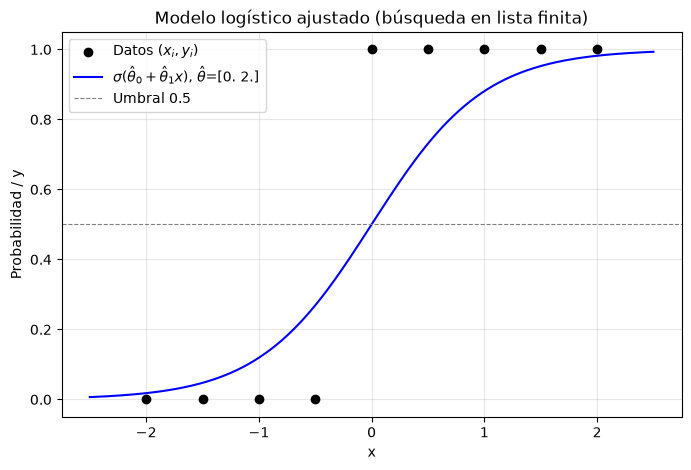

In [9]:
# Creamos un rango fino de valores de x para dibujar una curva suave
x_curva = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)

# Calculamos sigma(theta0_hat + theta1_hat * x) sobre ese rango
y_curva = compute_probs(theta_optimo, x_curva)

plt.figure(figsize=(8, 5))

# a) los datos originales (x_i, y_i)
plt.scatter(x, y, color='black', label='Datos $(x_i, y_i)$', zorder=3)

# b) la curva sigmoide con el theta óptimo
plt.plot(x_curva, y_curva, color='blue', 
          label=fr'$\sigma(\hat\theta_0 + \hat\theta_1 x)$, $\hat\theta$={theta_optimo}')

plt.xlabel('x')
plt.ylabel('Probabilidad / y')
plt.title('Modelo logístico ajustado (búsqueda en lista finita)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Umbral 0.5')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
def softmax(t):
    """
    Función escalón (a pesar del nombre 'softmax' pedido en el enunciado,
    NO es la softmax multiclase habitual, sino un umbral duro):
        softmax(t) = 0 si t < 0
        softmax(t) = 1 si t >= 0
    
    Parámetros
    ----------
    t : float o np.ndarray
        Valor (o arreglo de valores) de entrada.
    
    Retorna
    -------
    float o np.ndarray (mismo tipo que la entrada)
        0 si t < 0, 1 si t >= 0.
    """
    return np.where(t >= 0, 1, 0)

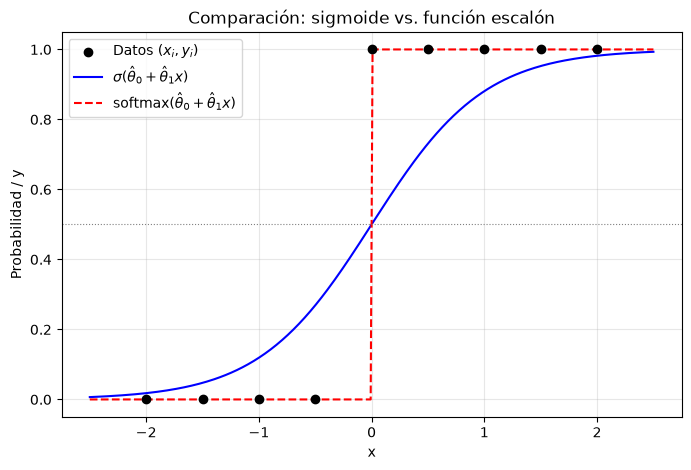

In [11]:
theta0_hat, theta1_hat = theta_optimo[0], theta_optimo[1]

# Evaluamos la función escalón sobre el mismo rango de x
z_curva = theta0_hat + theta1_hat * x_curva
y_softmax = softmax(z_curva)

plt.figure(figsize=(8, 5))

# a) los datos originales
plt.scatter(x, y, color='black', label='Datos $(x_i, y_i)$', zorder=3)

# b) la curva sigmoide
plt.plot(x_curva, y_curva, color='blue', 
          label=fr'$\sigma(\hat\theta_0 + \hat\theta_1 x)$')

# c) la función escalón
plt.plot(x_curva, y_softmax, color='red', linestyle='--',
          label=fr'$\mathrm{{softmax}}(\hat\theta_0 + \hat\theta_1 x)$')

plt.xlabel('x')
plt.ylabel('Probabilidad / y')
plt.title('Comparación: sigmoide vs. función escalón')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def sigmoid(t):
    """
    Calcula la función logística sigma(t) = 1 / (1 + e^(-t))
    """
    return 1 / (1 + np.exp(-t))

# Datos del ejercicio
x = np.array([-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

In [13]:
def logistic_loss(y_hat, y):
    """
    Calcula la pérdida logística puntual:
        l_log(y_hat, y) = -[ y*log(y_hat) + (1-y)*log(1-y_hat) ]
    
    Parámetros
    ----------
    y_hat : float o np.ndarray
        Probabilidad predicha (debe estar en (0,1)).
    y : float o np.ndarray
        Etiqueta observada (0 o 1).
    
    Retorna
    -------
    float o np.ndarray
        Valor(es) de la pérdida logística.
    """
    # eps evita log(0) por errores numéricos si y_hat es muy cercano a 0 o 1
    eps = 1e-12
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

In [14]:
def empirical_risk(theta, x, y):
    """
    Calcula el riesgo empírico del modelo logístico con parámetro theta,
    sobre la muestra (x, y).
    
    Parámetros
    ----------
    theta : np.ndarray de forma (2,)
        theta[0] = theta0, theta[1] = theta1
    x, y : np.ndarray
        Datos de entrada y etiquetas.
    
    Retorna
    -------
    float
        El riesgo empírico R_S_hat(theta).
    """
    theta0, theta1 = theta[0], theta[1]
    y_hat = sigmoid(theta0 + theta1 * x)   # probabilidades predichas
    perdidas = logistic_loss(y_hat, y)      # pérdida por cada observación
    return np.mean(perdidas)                # promedio = riesgo empírico

In [15]:
# a) función objetivo que recibe solo theta (x, y quedan fijos)
def objetivo(theta):
    return empirical_risk(theta, x, y)

# b) valor inicial
theta_init = np.array([0.0, 0.0])

# c) optimización numérica
resultado = minimize(objetivo, theta_init)

# d) extraer theta_hat del resultado
theta_hat = resultado.x

print(resultado)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.0074975641291329e-05
        x: [ 9.416e+00  4.200e+01]
      nit: 19
      jac: [-8.009e-06 -5.166e-07]
 hess_inv: [[ 3.316e+04  1.434e+05]
            [ 1.434e+05  6.204e+05]]
     nfev: 60
     njev: 20


In [16]:
print(f"theta_hat encontrado por el optimizador: {theta_hat}")
print(f"theta0_hat = {theta_hat[0]:.4f}")
print(f"theta1_hat = {theta_hat[1]:.4f}")
print(f"Riesgo empírico mínimo: {resultado.fun:.6f}")

theta_hat encontrado por el optimizador: [ 9.41635756 42.00452063]
theta0_hat = 9.4164
theta1_hat = 42.0045
Riesgo empírico mínimo: 0.000010


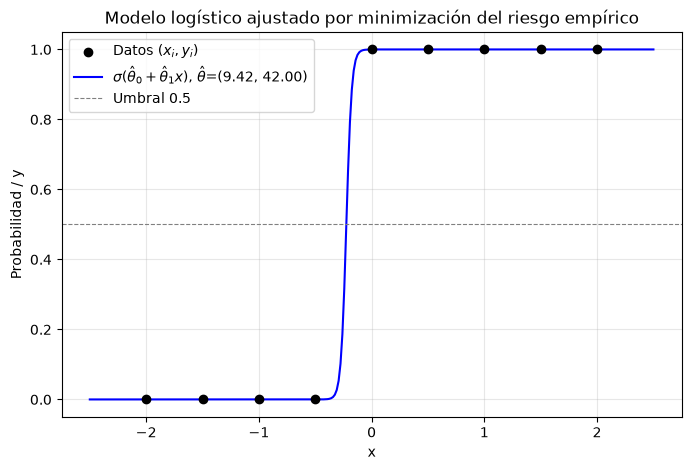

In [17]:
x_curva = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
y_curva = sigmoid(theta_hat[0] + theta_hat[1] * x_curva)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='black', label='Datos $(x_i, y_i)$', zorder=3)
plt.plot(x_curva, y_curva, color='blue', 
          label=fr'$\sigma(\hat\theta_0 + \hat\theta_1 x)$, $\hat\theta$=({theta_hat[0]:.2f}, {theta_hat[1]:.2f})')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Umbral 0.5')
plt.xlabel('x')
plt.ylabel('Probabilidad / y')
plt.title('Modelo logístico ajustado por minimización del riesgo empírico')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

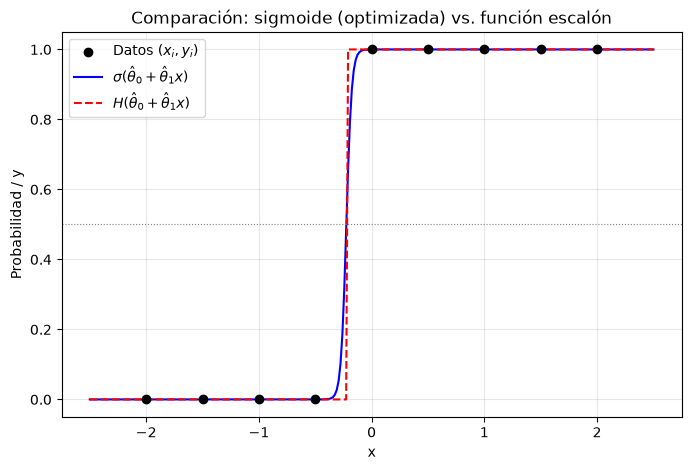

In [18]:
def softmax(t):
    """
    Función escalón:
        H(t) = 0 si t < 0
        H(t) = 1 si t >= 0
    (Se nombra 'softmax' por instrucción del enunciado, aunque
    no corresponde a la softmax multiclase habitual)
    """
    return np.where(t >= 0, 1, 0)

z_curva = theta_hat[0] + theta_hat[1] * x_curva
y_softmax = softmax(z_curva)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='black', label='Datos $(x_i, y_i)$', zorder=3)
plt.plot(x_curva, y_curva, color='blue', label=r'$\sigma(\hat\theta_0 + \hat\theta_1 x)$')
plt.plot(x_curva, y_softmax, color='red', linestyle='--', label=r'$H(\hat\theta_0 + \hat\theta_1 x)$')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('x')
plt.ylabel('Probabilidad / y')
plt.title('Comparación: sigmoide (optimizada) vs. función escalón')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Usamos theta_hat obtenido en el Ejercicio 2 (scipy.optimize.minimize)
p = sigmoid(theta_hat[0] + theta_hat[1] * x)
print("p_i =", p)

p_i = [4.02540033e-33 5.32077434e-24 7.03299976e-15 9.29613298e-06
 9.99918625e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00]


In [20]:
def logit(p):
    """
    Calcula la función logit:
        logit(p) = log(p / (1 - p))
    
    Parámetros
    ----------
    p : float o np.ndarray
        Probabilidad(es) en (0, 1).
    
    Retorna
    -------
    float o np.ndarray
        El valor de logit(p).
    """
    return np.log(p / (1 - p))

z = logit(p)
print("z_i =", z)

z_i = [-74.5926837  -53.59042339 -32.58816307 -11.58590276   9.41635756
  30.41963588          inf          inf          inf]


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_19624\1183935380.py:16: RuntimeWarning: divide by zero encountered in divide
  return np.log(p / (1 - p))


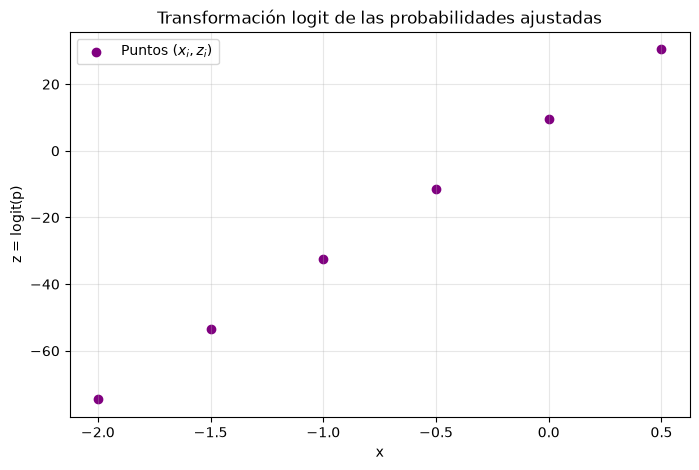

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(x, z, color='purple', label='Puntos $(x_i, z_i)$')
plt.xlabel('x')
plt.ylabel('z = logit(p)')
plt.title('Transformación logit de las probabilidades ajustadas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# np.polyfit ajusta z = b*x + a (grado 1), devuelve [pendiente, intercepto]
coef = np.polyfit(x, z, deg=1)
b_reg, a_reg = coef[0], coef[1]

print(f"Regresión lineal ajustada: z = {a_reg:.6f} + {b_reg:.6f} * x")
print(f"Intercepto (a) = {a_reg:.6f}")
print(f"Pendiente (b)  = {b_reg:.6f}")

Regresión lineal ajustada: z = nan + nan * x
Intercepto (a) = nan
Pendiente (b)  = nan


In [23]:
print("Comparación de coeficientes:")
print(f"  theta0_hat (Ejercicio 2) = {theta_hat[0]:.6f}   vs.   a (regresión) = {a_reg:.6f}")
print(f"  theta1_hat (Ejercicio 2) = {theta_hat[1]:.6f}   vs.   b (regresión) = {b_reg:.6f}")

Comparación de coeficientes:
  theta0_hat (Ejercicio 2) = 9.416358   vs.   a (regresión) = nan
  theta1_hat (Ejercicio 2) = 42.004521   vs.   b (regresión) = nan


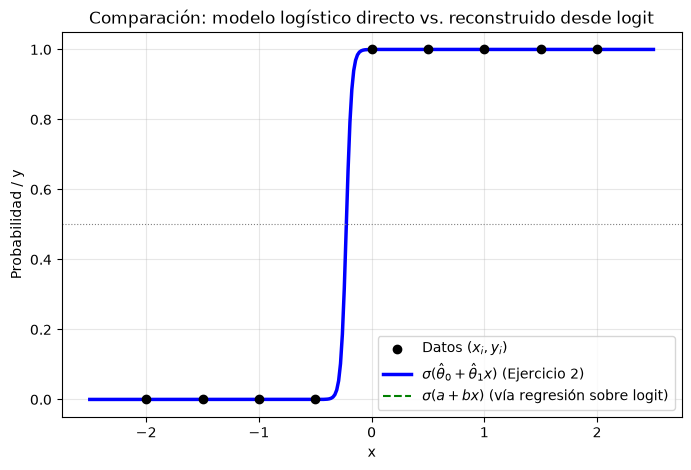

In [24]:
p_regresion = sigmoid(a_reg + b_reg * x_curva)  # usando x_curva del Ejercicio 2

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='black', label='Datos $(x_i, y_i)$', zorder=3)
plt.plot(x_curva, y_curva, color='blue', linewidth=2.5,
          label=fr'$\sigma(\hat\theta_0+\hat\theta_1x)$ (Ejercicio 2)')
plt.plot(x_curva, p_regresion, color='green', linestyle='--',
          label=fr'$\sigma(a+bx)$ (vía regresión sobre logit)')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('x')
plt.ylabel('Probabilidad / y')
plt.title('Comparación: modelo logístico directo vs. reconstruido desde logit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()